Instead of using the continuous variance of methane vs. forcing timescale, I think a better one-to-one comparison would be to use the "growth rate" of annual average methane. This would be calculated as the difference in annual average methane concentration from one year to the next, which is what is actually used in modern methane obs. I hope to better comment on modern methane here:
- currently, both the timescale and magnitude of variability in ice core methane are not comparable to modern methane variability. It is too slow and small in magnitude. If I can show that the true variability *could* be comparable to modern methane variability, that would be interesting.
- ergo, constraining the magnitude of paleo-methane variability is important to understand the drivers of modern methane variability. 

Expectations:
1. Growth rate will increase as forcing timescale decreases, as with variance.
2. Growth rate will level off at short timescales, as with variance.

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
from hydra import compose, initialize
from pathlib import Path
from methane_noise_forcing import closed_form
from methane_noise_forcing.core import FirnFilter
from methane_noise_forcing import average_to_resolution, calculate_mean_and_ci
from methane_noise_forcing.noise import simulate_two_timescale_ar1
from methane_noise_forcing.plotting.constants import matplotlib_rcparams, colors_vibrant, fig_width_options
import matplotlib.pyplot as plt
plt.rcParams.update(matplotlib_rcparams)
fig_width = fig_width_options["one_column"]
plt.rcParams['figure.dpi'] = 200

In [2]:
## colors of the lines for each timescale in the PSD plot
colors = {
    0.01: colors_vibrant["blue"],
    0.1: colors_vibrant["orange"],
    1.0: colors_vibrant["grey"],
    10.0: colors_vibrant["red"],
    100.0: colors_vibrant["cyan"],
    1000.0: colors_vibrant["grey"],
}

# Testing with one atmospheric variance target

In [3]:
## function for simulating noise
def simulate_multiple_realizations(timescales, var_C_target, tau_C, n_years, dt, n_ensemble):
    """
    Simulate multiple realizations of methane time series with different forcing timescales.
    
    Parameters:
    - timescales: list of forcing timescales (in years)
    - var_C_target: target variance of methane concentration (in ppb^2)
        - can be a single value or a list of values with the same length and order as timescales
    """
    two_timescale_noise = []
    for i, tau_eta in enumerate(timescales):
        if isinstance(var_C_target, (list, np.ndarray)):
            var_C = var_C_target[i]
        else:
            var_C = var_C_target
        
        x_ens, eta_ens = simulate_two_timescale_ar1(
            tau_x=tau_C,
            tau_eta=tau_eta,
            variance_x=var_C,
            n_steps=int(n_years / dt),
            dt=dt,
            n_ens=n_ensemble,
        )
        
        ds = xr.Dataset(
        {
            "ch4": (("ensemble", "time"), x_ens),
            "forcing": (("ensemble", "time"), eta_ens),
        },
        coords={
            "time": (("time"), np.arange(0, n_years, dt)),
            "ensemble": (("ensemble"), np.arange(n_ensemble)),
        },
    )
        # add dim for timescale to dataset
        ds = ds.expand_dims({"forcing_timescale": [tau_eta]})
        ds = ds.assign_coords({"forcing_timescale": ("forcing_timescale", [tau_eta])})

        two_timescale_noise.append(ds)
    return xr.concat(two_timescale_noise, dim="forcing_timescale")

In [4]:
## simulate with one atmospheric variance target first to see behavior of 
timescales = [0.01, 0.1, 1.0, 10.0, 100, 1000]
var_C_target = 100.0  # Target variance for methane anomaly in ppb^2
n_ensemble = 100
tau_C = 12 # years
dt_small = 0.01 # Time step in years
n_years = 1000 # years

two_timescale_noise = simulate_multiple_realizations(
    timescales=timescales,
    var_C_target=var_C_target,
    tau_C=tau_C,
    n_years=n_years,
    dt=dt_small,
    n_ensemble=n_ensemble
)

In [5]:
## average to annual resolution, then calculate growth over some lag
dt_annual = 1.0
change_interval = 1
lag = int(change_interval / dt_annual)

two_timescale_noise_annual = average_to_resolution(two_timescale_noise, resolution=dt_annual, time_dim="time")

# lagged difference: x[t] - x[t-lag]
noise_change = two_timescale_noise_annual - two_timescale_noise_annual.shift(time=lag)
# drop the leading NaNs introduced by the shift
noise_change = noise_change.isel(time=slice(lag, None))

noise_change_abs = np.abs(noise_change)

# validation
ch4_annual_slice = two_timescale_noise_annual.ch4.isel(ensemble=0, forcing_timescale=0).values
ch4_change_direct = ch4_annual_slice[lag:] - ch4_annual_slice[:-lag]
np.allclose(noise_change.ch4.isel(ensemble=0, forcing_timescale=0).values, ch4_change_direct)

True

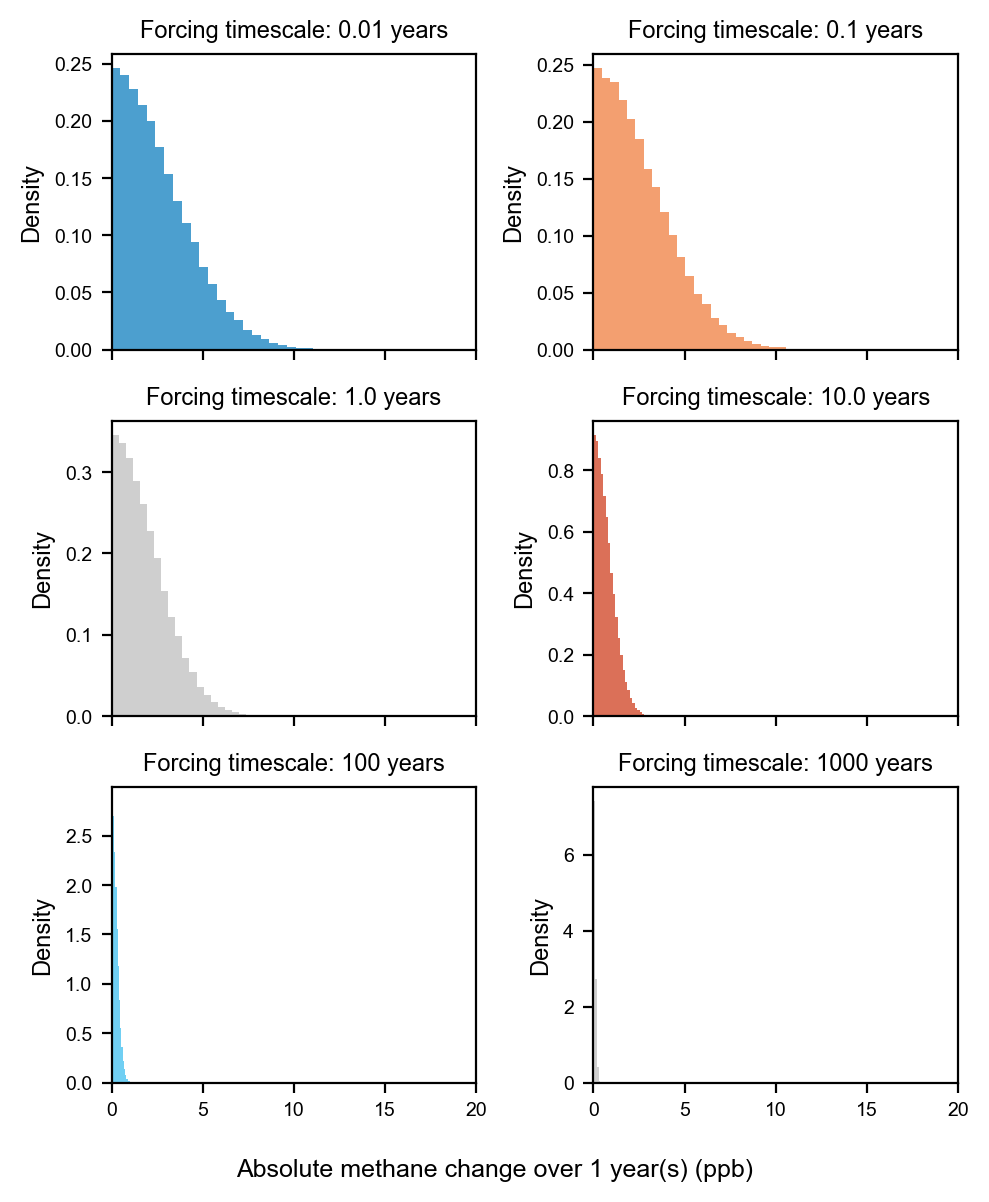

In [6]:
## plot histograms
#  2 columns, floor(len(timescales)/2) rows
xlim = (0, 20)
nrows = np.ceil(len(timescales)/2).astype(int)
fig, axs = plt.subplots(nrows=nrows, ncols=2, figsize=(5, 2*nrows), sharex=True, sharey=False)

axs = axs.flatten()
for i, timescale in enumerate(timescales):
    ax = axs[i]
    noise_change_abs.ch4.sel(forcing_timescale=timescale).plot.hist(
        bins=30,
        density=True,
        alpha=0.7,
        ax=ax,
        color=colors[timescale],
    )
    ax.set_title(f"Forcing timescale: {timescale} years")
    ax.set_ylabel("Density")
    ax.set_xlabel("")

axs[-1].set_xlim(xlim)

fig.supxlabel(f"Absolute methane change over {change_interval} year(s) (ppb)", fontsize=9)

plt.tight_layout()

Text(0, 0.5, 'Absolute methane change over 1 years (ppb)')

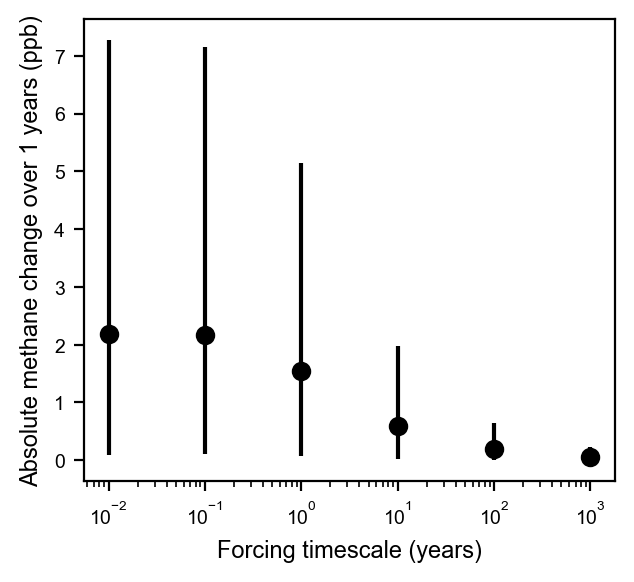

In [7]:
## plot quantiles sweeping over timescales
fig, ax = plt.subplots(figsize=(fig_width,3))

for timescale in timescales:
    mean, ci_lower, ci_upper = calculate_mean_and_ci(
        noise_change_abs.ch4.sel(forcing_timescale=timescale),
        dim=["ensemble", "time"],
    )
    median = noise_change_abs.ch4.sel(forcing_timescale=timescale).median(dim=["ensemble", "time"])
    ax.errorbar(
        timescale,
        median,
        yerr=[[median - ci_lower], [ci_upper - median]],
        fmt='o',
        label=f"τ={timescale} yr",
        color='k'
    )

ax.set_xscale('log')
ax.set_xlabel("Forcing timescale (years)")
ax.set_ylabel(f"Absolute methane change over {change_interval} years (ppb)")

# test with multiple atmospheric variance targets
aka use firn kernel to calculate atmospheric variance necessary to sustain ice core variance of 100 ppb^2.

In [8]:
## global parameters
with initialize(version_base=None, config_path="../configs"):  # configs with data paths
    cfg = compose(config_name="config", overrides=[
        "+noise=white_noise_ar1",
        "++noise.duration_timeseries=4750",
        "+firn_kernel=firn_model_wais",])
    
variance_filtered_methane = 100 # ppb^2
taus_methane = np.arange(7, 13.2, 0.2) # years
n_lag_years = 80 # number of year lags to calculate
a, b = -2, 3 # log10 years
m = 10 # samples per decade
num = (b - a) * m + 1 # number of samples
taus_forcing = np.logspace(a, b, num) # years

In [9]:
## calculate filter overlap
firn_filter = FirnFilter.fit_from_config(
    kernel_type=cfg.firn_kernel.type,
    parameters=cfg.firn_kernel.parameters,
    path_root=cfg.paths.firn_filters_root
)

dt = firn_filter.dt  # years
lags = np.arange(0, n_lag_years / dt, 1) # years

c_taus = closed_form.calculate_kernel_self_lag(
    kernel=firn_filter.kernel / np.sum(firn_filter.kernel) ,
    lags=lags,
)

In [10]:
## calculate atmospheric variance necessary to sustain ice core variance of 100 ppb^2
instantaneous_methane_variance = xr.DataArray(
    np.zeros((len(taus_methane), len(taus_forcing))),
    dims=["taus_methane", "taus_forcing"],
    coords={
        "taus_methane": taus_methane,
        "taus_forcing": taus_forcing,
    },
)
for tau_methane in taus_methane:
    for tau_forcing in taus_forcing:
        autocorrelations = closed_form.calculate_two_timescale_autocorrelation(
            phi_0=np.exp(-dt / tau_methane),
            phi_1=np.exp(-dt / tau_forcing),
            lags=lags,
        )
        variance_ratio_filtered_to_instantaneous = closed_form.calculate_variance_ratio_filtered_to_instantaneous(
            c_taus=c_taus,
            instantaneous_autocorrelations=autocorrelations
        )
        instantaneous_methane_variance.loc[dict(
            taus_methane=tau_methane,
            taus_forcing=tau_forcing,
        )] = variance_filtered_methane / variance_ratio_filtered_to_instantaneous

In [11]:
## calculate growth rates
n_ensemble = 100
tau_C = 10 # years
dt_small = 0.01 # Time step in years
n_years = 1000 # years

two_timescale_noise = simulate_multiple_realizations(
    timescales=timescales,
    var_C_target=instantaneous_methane_variance.sel(taus_methane=tau_C, taus_forcing=timescales, method="nearest").values,
    tau_C=tau_C,
    n_years=n_years,
    dt=dt_small,
    n_ensemble=n_ensemble
)

In [12]:
## average to annual resolution, then calculate growth over some lag
dt_annual = 1.0
change_interval = 10
lag = int(change_interval / dt_annual)

two_timescale_noise_annual = average_to_resolution(two_timescale_noise, resolution=dt_annual, time_dim="time")

# lagged difference: x[t] - x[t-lag]
noise_change = two_timescale_noise_annual - two_timescale_noise_annual.shift(time=lag)
# drop the leading NaNs introduced by the shift
noise_change = noise_change.isel(time=slice(lag, None))

noise_change_abs = np.abs(noise_change)

# validation
ch4_annual_slice = two_timescale_noise_annual.ch4.isel(ensemble=0, forcing_timescale=0).values
ch4_change_direct = ch4_annual_slice[lag:] - ch4_annual_slice[:-lag]
np.allclose(noise_change.ch4.isel(ensemble=0, forcing_timescale=0).values, ch4_change_direct)

True

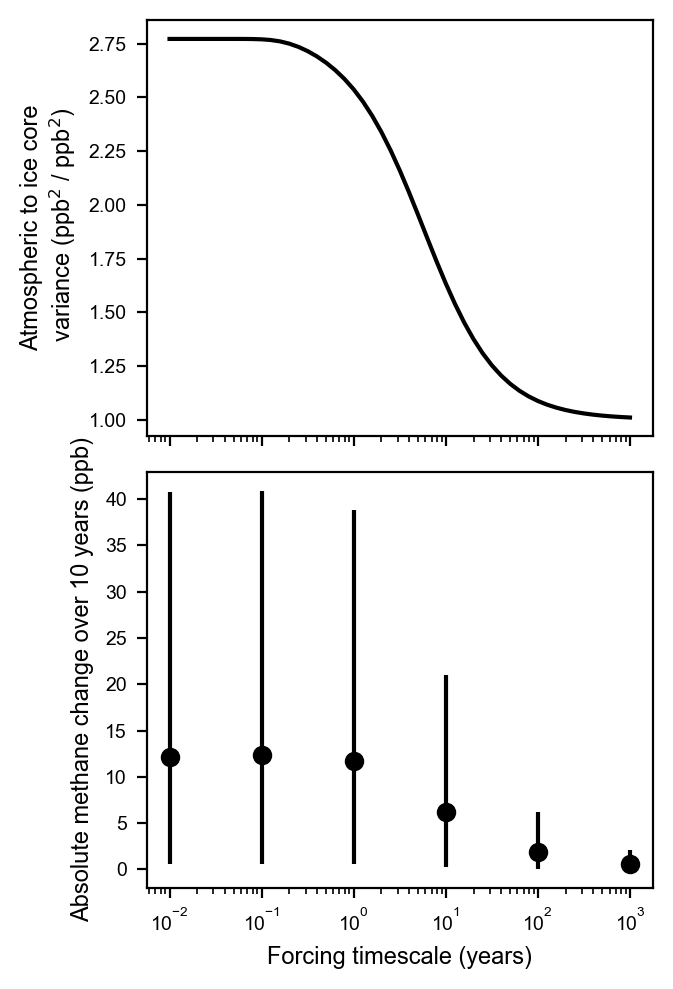

In [13]:
## plot quantiles sweeping over timescales
fig, axs = plt.subplots(2, 1, figsize=(fig_width, 5), sharex=True)

# instantaneous standard deviation
axs[0].plot(
    taus_forcing,
    instantaneous_methane_variance.sel(taus_methane=tau_C, method="nearest").values / 100,
    color="k"
)
axs[0].set_ylabel("Atmospheric to ice core\n variance (ppb$^2$ / ppb$^2$)")

# change in methane over some interval
for timescale in timescales:
    mean, ci_lower, ci_upper = calculate_mean_and_ci(
        noise_change_abs.ch4.sel(forcing_timescale=timescale),
        dim=["ensemble", "time"],
    )
    median = noise_change_abs.ch4.sel(forcing_timescale=timescale).median(dim=["ensemble", "time"])
    axs[1].errorbar(
        timescale,
        median,
        yerr=[[median - ci_lower], [ci_upper - median]],
        fmt='o',
        label=f"τ={timescale} yr",
        color='k'
    )

axs[1].set_xscale('log')
axs[1].set_xlabel("Forcing timescale (years)")
axs[1].set_ylabel(f"Absolute methane change over {change_interval} years (ppb)")

plt.tight_layout()

As expected, the change in atmospheric methane increases as forcing timescale decreases, and levels off at short timescales. The change is also larger for larger atmospheric variance targets by a linear factor, which can be backed out with the relationship to the firn filter. Changes at timescales of 1 year and lower appear to be pretty large. It remains to be seen whether these changes encompass the observed variability in modern methane, though they seem to explain at least 50% of the variability.

Increasing the time lag causes larger changes, as expected. (e.g., 30 ppb changes over 5 years rather than 12 ppb changes over 1 year), but these changes level off logarithmically with increasing lag time. Increasing the lag also causes the larger timescales to level off, which I *think* is expected, but I need to think about it more.

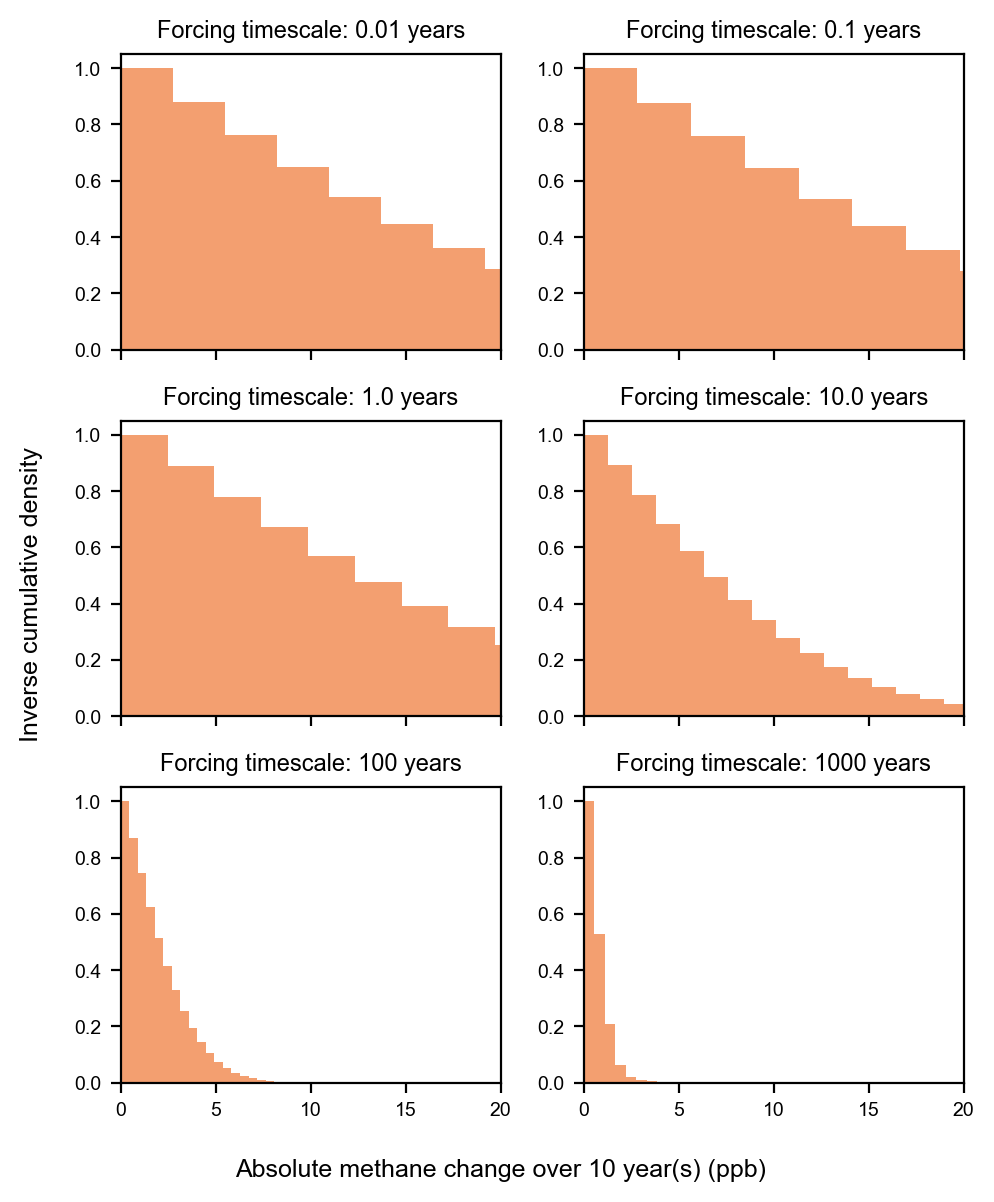

In [14]:
## plot histograms
#  2 columns, floor(len(timescales)/2) rows
cumulative=-1 # False or -1 (inverse CDF)
xlim = (0, 20)
nrows = np.ceil(len(timescales)/2).astype(int)
fig, axs = plt.subplots(nrows=nrows, ncols=2, figsize=(5, 2*nrows), sharex=True, sharey=False)

axs = axs.flatten()
for i, timescale in enumerate(timescales):
    ax = axs[i]
    noise_change_abs.ch4.sel(forcing_timescale=timescale).plot.hist(
        bins=30,
        density=True,
        cumulative=cumulative,
        alpha=0.7,
        ax=ax,
        color=colors_vibrant["orange"],
    )
    ax.set_title(f"Forcing timescale: {timescale} years")
    ax.set_xlabel("")

axs[-1].set_xlim(xlim)

ylabel = "Inverse cumulative density" if cumulative==-1 else "Density"
fig.supylabel(ylabel, fontsize=9)
fig.supxlabel(f"Absolute methane change over {change_interval} year(s) (ppb)", fontsize=9)

plt.tight_layout()

## comparison to modern methane

In [15]:
# load obs
data_dir = Path(cfg.paths.observations_cultivated)
obs_modern = pd.read_csv(data_dir / "ch4_modern_detrended.csv")
obs_modern["ch4_change_detrended"] = obs_modern["ch4_detrended"].diff(periods=lag)
obs_modern["ch4_change_detrended_abs"] = np.abs(obs_modern["ch4_change_detrended"])

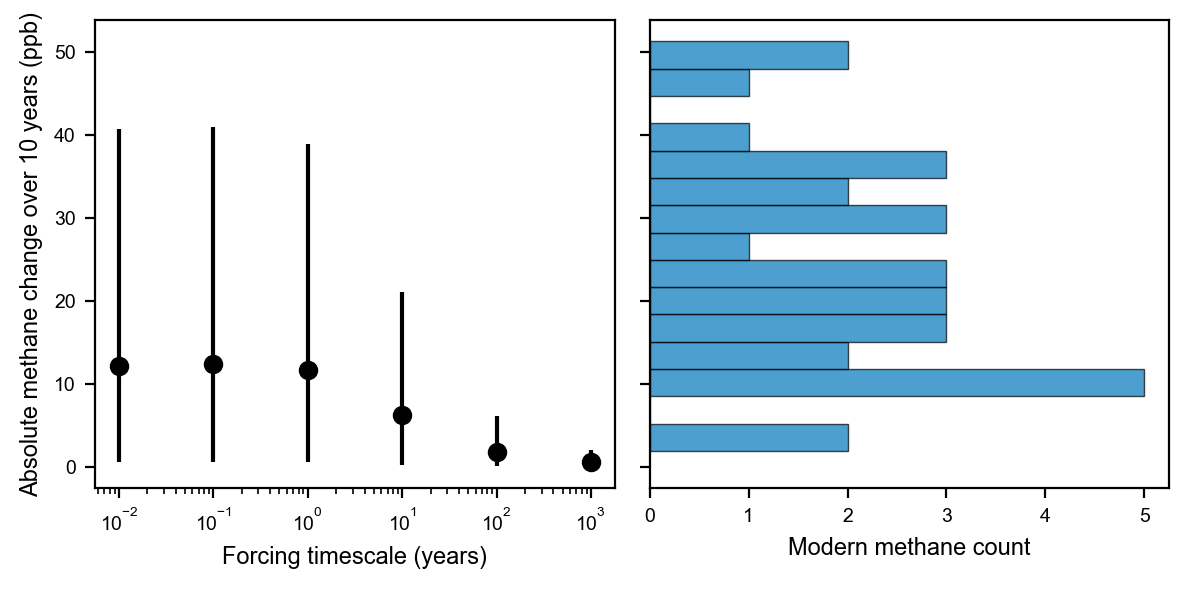

In [16]:
# plot change in methane over some interval against observed histogram
fig, axs = plt.subplots(1, 2, figsize=(fig_width_options["two_column_large"]-1, 3), sharey=True)
axs = axs.flatten()

# first panel same as above
for timescale in timescales:
    mean, ci_lower, ci_upper = calculate_mean_and_ci(
        noise_change_abs.ch4.sel(forcing_timescale=timescale),
        dim=["ensemble", "time"],
    )
    median = noise_change_abs.ch4.sel(forcing_timescale=timescale).median(dim=["ensemble", "time"])
    axs[0].errorbar(
        timescale,
        median,
        yerr=[[median - ci_lower], [ci_upper - median]],
        fmt='o',
        label=f"τ={timescale} yr",
        color='k'
    )
axs[0].set_xscale('log')
axs[0].set_xlabel("Forcing timescale (years)")
axs[0].set_ylabel(f"Absolute methane change over {change_interval} years (ppb)")

# plot histogram of observed changes
obs_modern["ch4_change_detrended_abs"].hist(
    ax=axs[1],
    bins=15,
    density=False,
    alpha=0.7,
    orientation="horizontal",
    color=colors_vibrant["blue"],
    edgecolor='k',
    linewidth=0.5,
)
axs[1].grid(False)
axs[1].set_xlabel("Modern methane count")

plt.tight_layout()

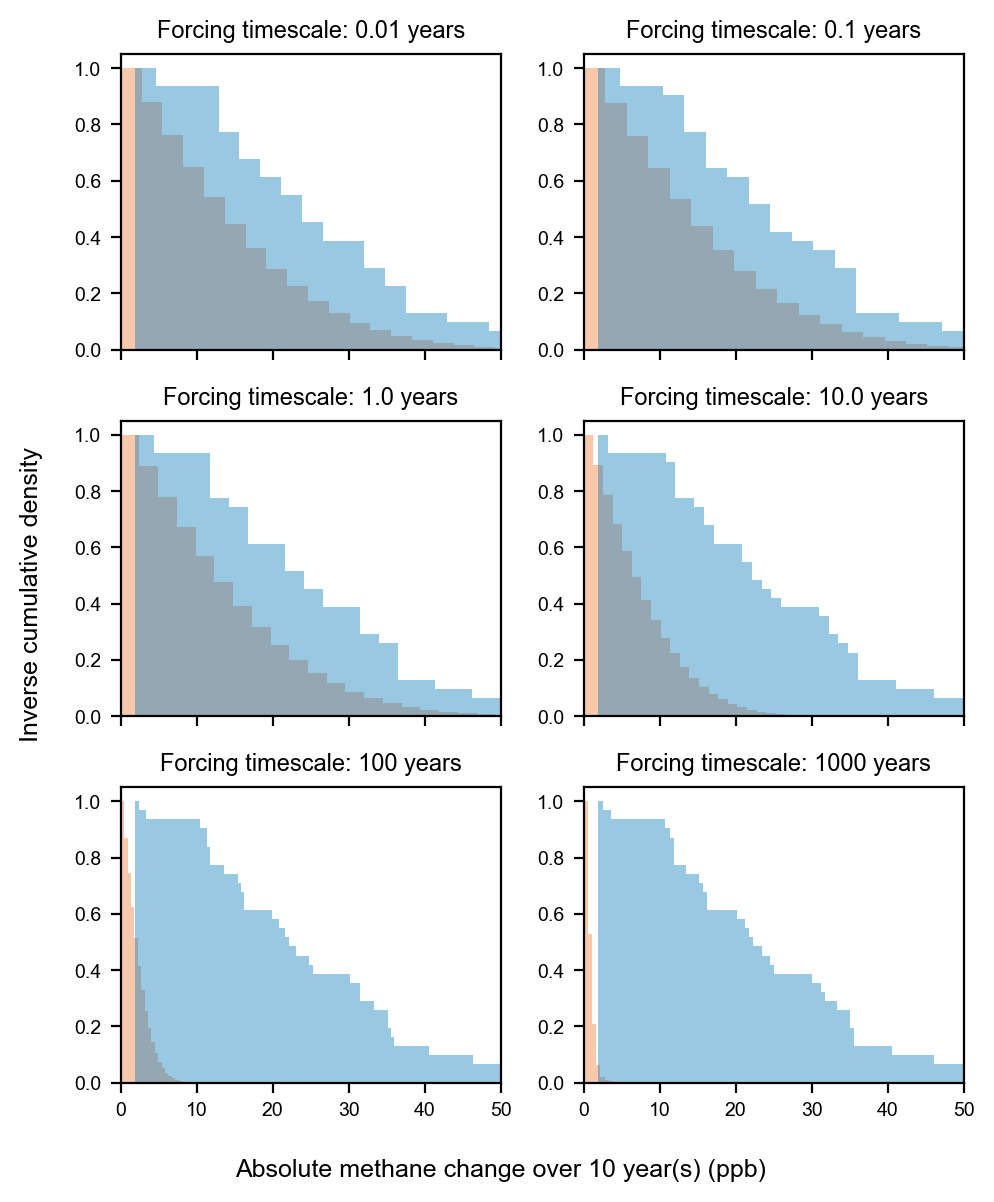

In [17]:
## plot histograms
#  2 columns, floor(len(timescales)/2) rows
cumulative=-1 # False or -1 (inverse CDF)
xlim = (0, 50)
nrows = np.ceil(len(timescales)/2).astype(int)
fig, axs = plt.subplots(nrows=nrows, ncols=2, figsize=(5, 2*nrows), sharex=True, sharey=False)

axs = axs.flatten()
for i, timescale in enumerate(timescales):
    ax = axs[i]
    
    # Get the data for binning
    noise_data = noise_change_abs.ch4.sel(forcing_timescale=timescale).values.flatten()
    obs_data = obs_modern["ch4_change_detrended_abs"].dropna().values
    
    # Calculate bin width from noise data
    _, noise_bin_edges = np.histogram(noise_data, bins=30, density=True)
    bin_width = noise_bin_edges[1] - noise_bin_edges[0]
    
    # Create bins for obs data using the same width but covering its full range
    obs_min, obs_max = obs_data.min(), obs_data.max()
    obs_bins = np.arange(obs_min, obs_max + bin_width, bin_width)
    
    # Plot noise histogram using original bins
    noise_change_abs.ch4.sel(forcing_timescale=timescale).plot.hist(
        bins=noise_bin_edges,
        density=True,
        cumulative=cumulative,
        alpha=0.4,
        ax=ax,
        color=colors_vibrant["orange"],
    )
    
    # Plot obs histogram using bins with same width but different range
    obs_modern["ch4_change_detrended_abs"].hist(
        ax=axs[i],
        bins=obs_bins,
        density=True,
        cumulative=cumulative,
        alpha=0.4,
        color=colors_vibrant["blue"],
    )
    
    ax.set_title(f"Forcing timescale: {timescale} years")
    ax.set_xlabel("")
    ax.grid(False)

axs[-1].set_xlim(xlim)

ylabel = "Inverse cumulative density" if cumulative==-1 else "Density"
fig.supylabel(ylabel, fontsize=9)
fig.supxlabel(f"Absolute methane change over {change_interval} year(s) (ppb)", fontsize=9)

plt.tight_layout()